In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
print(sys.executable)

/home/iztihad/venvs/ml/bin/python


In [4]:
model_config = {
    "batch_size": 16,
    "input_size": 224,
    "learning_rate": 0.001,
    "epochs": 20,
    "pretrained":True
}

In [5]:
gpu = torch.device("cuda")

In [6]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),

    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])
}

train_dir = "../BanglaLekha_dataset_split/train"
val_dir = "../BanglaLekha_dataset_split/validation"
test_dir = "../BanglaLekha_dataset_split/test"


train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms["train"])
val_dataset = datasets.ImageFolder(root=val_dir, transform=data_transforms["val"])
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms["test"])

train_dataloader = DataLoader(train_dataset, batch_size=model_config["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=model_config["batch_size"], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=model_config["batch_size"], shuffle=False)

In [7]:
def validate_model(model1, model2, val_dataloader, factor):
    with torch.no_grad():
        model1.eval()
        model2.eval()
        total = 0
        total_correct = 0

        class_freq = np.zeros(84, dtype=int)
        class_corr_freq = np.zeros(84, dtype=int)

        for images, labels in val_dataloader:
            images = images.to(gpu)
            labels = labels.to(gpu)

            output1 = model1(images)
            output2 = model2(images)
            
            output = factor*output1 + (1-factor)*output2
            _, predicted = torch.max(output, 1)

            total = total + len(labels)
            # print(predicted.shape)
            # print(labels.shape)

            for i in range(0, predicted.size(0)):
                class_freq[labels[i]]+=1
                if(predicted[i] == labels[i]):
                    total_correct+=1
                    class_corr_freq[predicted[i]]+=1

            # total_correct = total_correct + (predicted == labels).sum().item()

        return total_correct/total, class_freq, class_corr_freq



MobileNet_v2

In [9]:

mobilenet_v2 = models.mobilenet_v2(pretrained=True)


for param in mobilenet_v2.parameters():
    param.requires_grad = False

mobilenet_v2.classifier[1] = nn.Linear(mobilenet_v2.last_channel, 84)

total_params_mobnet = sum(p.numel() for p in mobilenet_v2.parameters())

gpu = torch.device("cuda")
mobilenet_v2 = mobilenet_v2.to(gpu)


In [10]:
mobilenet_v2.load_state_dict(torch.load("saved_parameters/mobilenet_v2.pth"))
mobilenet_v2.eval()
accuracy_mobnet, class_freq, class_corr_freq = validate_model(mobilenet_v2, mobilenet_v2, test_dataloader, 1)
basic_char_accuracy_mobnet = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_mobnet = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [11]:
print(f"Parameter Count: {(total_params_mobnet/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_mobnet: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_mobnet: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_mobnet: 0.2f}")

Parameter Count:  2.3 Million
Basic Character Accuracy:  92.35
Compound Character Accuracy:  90.23
Overall Accuracy:  91.74


EfficientNet_B0

In [15]:

efficientnet_b0 = models.efficientnet_b0(pretrained=True)


for param in efficientnet_b0.parameters():
    param.requires_grad = False

in_features = efficientnet_b0.classifier[1].in_features
efficientnet_b0.classifier[1] = nn.Linear(in_features, 84)

total_params_eff0 = sum(p.numel() for p in efficientnet_b0.parameters())

gpu = torch.device("cuda")
efficientnet_b0 = efficientnet_b0.to(gpu)


In [16]:
efficientnet_b0.load_state_dict(torch.load("saved_parameters/efficientnet_b0.pth"))
efficientnet_b0.eval()
accuracy_eff0, class_freq, class_corr_freq = validate_model(efficientnet_b0, efficientnet_b0, test_dataloader, 1)
basic_char_accuracy_eff0 = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_eff0 = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [17]:
print(f"Parameter Count: {(total_params_eff0/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_eff0: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_eff0: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_eff0: 0.2f}")

Parameter Count:  4.1 Million
Basic Character Accuracy:  94.27
Compound Character Accuracy:  92.01
Overall Accuracy:  93.62


MobileViT_s

In [24]:

mobilevit_s = timm.create_model("mobilevit_s", pretrained=True)

for params in mobilevit_s.parameters():
    params.requires_grad = False

mobilevit_s.reset_classifier(84)


total_params_mobvit = sum(p.numel() for p in mobilevit_s.parameters())

gpu = torch.device("cuda")
mobilevit_s = mobilevit_s.to(gpu)


In [25]:
mobilevit_s.load_state_dict(torch.load("saved_parameters/mobile_ViT.pth"))
mobilevit_s.eval()
accuracy_mobvit, class_freq, class_corr_freq = validate_model(mobilevit_s, mobilevit_s, test_dataloader, 1)
basic_char_accuracy_mobvit = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_mobvit = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [26]:
print(f"Parameter Count: {(total_params_mobvit/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_mobvit: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_mobvit: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_mobvit: 0.2f}")

Parameter Count:  5.0 Million
Basic Character Accuracy:  92.65
Compound Character Accuracy:  88.88
Overall Accuracy:  91.58


EfficientViT_B1

In [27]:

efficientvit_b1 = timm.create_model("efficientvit_b1", pretrained=True)

for params in efficientvit_b1.parameters():
    params.requires_grad = False

efficientvit_b1.reset_classifier(84)


total_params_effvit = sum(p.numel() for p in efficientvit_b1.parameters())

gpu = torch.device("cuda")
efficientvit_b1 = efficientvit_b1.to(gpu)


In [28]:
efficientvit_b1.load_state_dict(torch.load("saved_parameters/efficient_ViT.pth"))
efficientvit_b1.eval()
accuracy_effvit, class_freq, class_corr_freq = validate_model(efficientvit_b1, efficientvit_b1, test_dataloader, 1)
basic_char_accuracy_effvit = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_effvit = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [29]:
print(f"Parameter Count: {(total_params_effvit/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_effvit: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_effvit: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_effvit: 0.2f}")

Parameter Count:  7.6 Million
Basic Character Accuracy:  92.93
Compound Character Accuracy:  91.25
Overall Accuracy:  92.45


EfficientNet_B2

In [41]:
efficientnet_b2 = models.efficientnet_b2(pretrained=True)


for param in efficientnet_b2.parameters():
    param.requires_grad = False

in_features = efficientnet_b2.classifier[1].in_features
efficientnet_b2.classifier[1] = nn.Linear(in_features, 84)

total_params_eff2 = sum(p.numel() for p in efficientnet_b2.parameters())

gpu = torch.device("cuda")
efficientnet_b2 = efficientnet_b2.to(gpu)


In [38]:
efficientnet_b2.load_state_dict(torch.load("saved_parameters/efficientnet_b2.pth"))
efficientnet_b2.eval()
accuracy_eff2, class_freq, class_corr_freq = validate_model(efficientnet_b2, efficientnet_b2, test_dataloader, 1)
basic_char_accuracy_eff2 = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_eff2 = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [42]:
print(f"Parameter Count: {(total_params_eff2/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_eff2: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_eff2: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_eff2: 0.2f}")

Parameter Count:  7.8 Million
Basic Character Accuracy:  94.42
Compound Character Accuracy:  92.48
Overall Accuracy:  93.86


TinyViT

In [19]:

tiny_vit = timm.create_model("tiny_vit_11m_224", pretrained=True)

for params in tiny_vit.parameters():
    params.requires_grad = False

tiny_vit.reset_classifier(84)


total_params_tiny = sum(p.numel() for p in tiny_vit.parameters())

gpu = torch.device("cuda")
tiny_vit = tiny_vit.to(gpu)


In [46]:
tiny_vit.load_state_dict(torch.load("saved_parameters/tiny_ViT.pth"))
tiny_vit.eval()
accuracy_tiny, class_freq, class_corr_freq = validate_model(tiny_vit, tiny_vit, test_dataloader, 1)
basic_char_accuracy_tiny = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_tiny = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [47]:
print(f"Parameter Count: {(total_params_tiny/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_tiny: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_tiny: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_tiny: 0.2f}")

Parameter Count:  10.6 Million
Basic Character Accuracy:  94.82
Compound Character Accuracy:  93.07
Overall Accuracy:  94.32


TinyViT + EfficientNet_B0

In [21]:
tiny_vit.load_state_dict(torch.load("saved_parameters/tiny_ViT.pth"))
efficientnet_b0.load_state_dict(torch.load("saved_parameters/efficientnet_b0.pth"))
tiny_vit.eval()
accuracy_tiny_eff0, class_freq, class_corr_freq = validate_model(tiny_vit, efficientnet_b0, test_dataloader, 0.54)
basic_char_accuracy_tiny_eff0 = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_tiny_eff0 = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [22]:
print(f"Parameter Count: {((total_params_tiny+total_params_eff0)/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_tiny_eff0: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_tiny_eff0: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_tiny_eff0: 0.2f}")

Parameter Count:  14.7 Million
Basic Character Accuracy:  95.48
Compound Character Accuracy:  93.65
Overall Accuracy:  94.95


TinyViT + EfficientNet_B2

In [43]:
tiny_vit.load_state_dict(torch.load("saved_parameters/tiny_ViT.pth"))
efficientnet_b2.load_state_dict(torch.load("saved_parameters/efficientnet_b2.pth"))
tiny_vit.eval()
accuracy_tiny_eff2, class_freq, class_corr_freq = validate_model(tiny_vit, efficientnet_b2, test_dataloader, 0.53)
basic_char_accuracy_tiny_eff2 = sum(class_corr_freq[0:60])/sum(class_freq[0:60])
compound_char_accuracy_tiny_eff2 = sum(class_corr_freq[60:84])/sum(class_freq[60:84])


In [44]:
print(f"Parameter Count: {((total_params_tiny+total_params_eff2)/1e6): 0.1f} Million")
print(f"Basic Character Accuracy: {100 * basic_char_accuracy_tiny_eff2: 0.2f}")
print(f"Compound Character Accuracy: {100 * compound_char_accuracy_tiny_eff2: 0.2f}")
print(f"Overall Accuracy: {100 * accuracy_tiny_eff2: 0.2f}")

Parameter Count:  18.4 Million
Basic Character Accuracy:  95.49
Compound Character Accuracy:  93.83
Overall Accuracy:  95.02


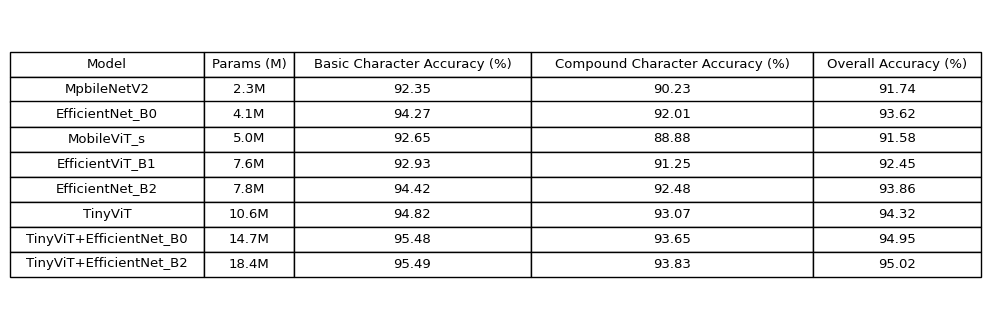

In [49]:
import matplotlib.pyplot as plt

# Example data (replace with yours)
fine_tuned_models = ["MpbileNetV2", "EfficientNet_B0", "MobileViT_s", "EfficientViT_B1", "EfficientNet_B2",
          "TinyViT","TinyViT+EfficientNet_B0", "TinyViT+EfficientNet_B2"]

params = [total_params_mobnet/1e6, total_params_eff0/1e6,
          total_params_mobvit/1e6, total_params_effvit/1e6,
           total_params_eff2/1e6, total_params_tiny/1e6,  
          (total_params_tiny+total_params_eff0)/1e6, (total_params_tiny+total_params_eff2)/1e6]  # in millions
basic_char_accuracy = [basic_char_accuracy_mobnet, basic_char_accuracy_eff0,
                        basic_char_accuracy_mobvit, basic_char_accuracy_effvit,
                        basic_char_accuracy_eff2, basic_char_accuracy_tiny, 
                        basic_char_accuracy_tiny_eff0, basic_char_accuracy_tiny_eff2]

compound_char_accuracy = [compound_char_accuracy_mobnet, compound_char_accuracy_eff0,
                        compound_char_accuracy_mobvit, compound_char_accuracy_effvit,
                        compound_char_accuracy_eff2, compound_char_accuracy_tiny, 
                        compound_char_accuracy_tiny_eff0, compound_char_accuracy_tiny_eff2]

accuracy = [accuracy_mobnet, accuracy_eff0,
            accuracy_mobvit, accuracy_effvit,
            accuracy_eff2, accuracy_tiny, 
            accuracy_tiny_eff0, accuracy_tiny_eff2]



# Combine data into rows
table_data = []
for i in range(len(fine_tuned_models)):
    table_data.append([
        fine_tuned_models[i],
        f"{params[i]:.1f}M",
        f"{100*basic_char_accuracy[i]:.2f}",
        f"{100*compound_char_accuracy[i]:.2f}",
        f"{100*accuracy[i]:.2f}"
    ])

# Column labels
columns = ["Model", "Params (M)", "Basic Character Accuracy (%)", "Compound Character Accuracy (%)", "Overall Accuracy (%)"]

# Create figure
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# Create table
table = ax.table(cellText=table_data,
                 colLabels=columns,
                 loc='center',
                 cellLoc='center')

# Styling
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.auto_set_column_width(col=list(range(len(columns))))
table.scale(1, 1.5)

plt.show()